In [214]:
import sys
sys.path.append("../../src/")
from project_imports import *
from scipy.integrate import solve_ivp
from numpy import conj
from numpy import linalg as la
import kibble_zurek as kz
from time import time
from joblib import Parallel, delayed
import numpy as np
import time_evolved_z_correlators as zz
#Load Pauli Matrices
s3,s1,s2 = array([[-1,0],[0,1]],dtype=complex),array([[0, 1],[1,0]],dtype=complex), array([[0,-1j],[1j,0]],dtype=complex)



In [225]:

# def g(t,tau,alpha=1):
#     """
#     Time Dependent g(t) with a potential nonlinearity in quench speed controlled by alpha.
#     """
#     return 1 - np.sign(t)*abs(t/tau)**(alpha)
#TFIM functions
def a(q,g):
    return g+ cos(q)
def b(q,g):
    return sin(q)
def w(q,g):
    return sqrt(g*g+2*g*cos(q)+1)
def BdG(q,g):
    return -2*(a(q,g)*s3+b(q,g)*s2)
###

def BdG_stationary_evolve(t,U,g,q):
    return -1j*BdG(q,g)@U
       

def evolve_mode(q,g0,gf,t_eval):
    V0 = la.eigh(BdG(q, g0))[1][:, 0]

    print(V0)
    sol = solve_ivp(
        BdG_stationary_evolve,
        [t_eval[0], t_eval[-1]],
        V0,
        args=(gf,q),
        t_eval=t_eval,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
        max_step=0.05,
    )
    return sol.y[0], sol.y[1]

def landau_states(L,g0,gf,t_eval):
    n = np.arange(0, L//2 )
    k = (2 * n + 1) * pi / L

    results = Parallel(n_jobs=-1, prefer="processes")(
        delayed(evolve_mode)(q, g0, gf, t_eval) for q in k
    )

    us, vs = map(np.array, zip(*results))

    states = [[us[:, i], vs[:, i], k] for i in range(len(t_eval))]
    return states, t_eval


In [226]:
def GroundStateOverlap(states):
    overlaps = []
    u0,v0,_ = states[0]
    for ui,vi,_ in states:
        overlaps.append( np.prod(np.abs(np.conj(u0)*ui+np.conj(v0)*vi))**2)
    return array(overlaps)

def GS_overlap(states,L,g0):
    overlaps=[]
    u0,v0,_=landau_states(L,g0,g0,array([0,.01]))[0][0]
    for ui,vi,_ in states:
        overlaps.append( np.prod(np.abs(np.conj(u0)*ui+np.conj(v0)*vi))**2)
    return array(overlaps)

def critical_times(gf,n):
    ek = 2*sqrt(gf**2+1)
    n_plot = np.arange(0,n)
    tns = (n_plot+1/2)*pi/ek
    return tns


In [233]:
g0= 200
gf = 0
ns = [2,3,4,5,6]
L =100


In [234]:
#Critical Times
tns = critical_times(gf,10)
t_eval = np.linspace(0,tns[-1],300)
#States Generation
states,t_eval= landau_states(L,g0,gf,t_eval)



[-7.81364077e-05-0.j  0.00000000e+00-1.j]
[-0.00023411-0.j          0.        -0.99999997j]
[-0.00038916-0.j          0.        -0.99999992j]
[-0.00054271-0.j          0.        -0.99999985j]
[-0.00069414-0.j          0.        -0.99999976j]
[-0.00084288-0.j          0.        -0.99999964j]
[-0.00098833-0.j          0.        -0.99999951j]
[-0.00112994-0.j          0.        -0.99999936j]
[-0.00126715-0.j         0.        -0.9999992j]
[-0.00139942-0.j          0.        -0.99999902j]
[-0.00152623-0.j          0.        -0.99999884j]
[-0.0016471-0.j          0.       -0.99999864j]
[-0.00176153-0.j          0.        -0.99999845j]
[-0.00186909-0.j          0.        -0.99999825j]
[-0.00196934-0.j          0.        -0.99999806j]
[-0.00206189-0.j          0.        -0.99999787j]
[-0.00214638-0.j         0.        -0.9999977j]
[-0.00222245-0.j          0.        -0.99999753j]
[-0.00228982-0.j          0.        -0.99999738j]
[-0.00234821-0.j          0.        -0.99999724j]
[-0.00239737-0

[-0.01570732-0.j          0.        -0.99987663j]
[-0.04710645-0.j          0.        -0.99888987j]
[-0.0784591-0.j          0.       -0.99691733j]
[-0.10973431-0.j          0.        -0.99396096j]
[-0.14090123-0.j          0.        -0.99002366j]
[-0.1719291-0.j          0.       -0.98510933j]
[-0.2027873-0.j          0.       -0.97922281j]
[-0.23344536-0.j          0.        -0.97236992j]
[-0.26387305-0.j          0.        -0.96455742j]
[-0.29404033-0.j          0.        -0.95579301j]
[-0.32391742-0.j          0.        -0.94608536j]
[-0.35347484-0.j          0.        -0.93544403j]
[-0.38268343-0.j          0.        -0.92387953j]
[-0.41151436-0.j          0.        -0.91140328j]
[-0.43993917-0.j          0.        -0.89802758j]
[-0.46792981-0.j          0.        -0.88376563j]
[-0.49545867-0.j          0.        -0.86863151j]
[-0.52249856-0.j          0.        -0.85264016j]
[-0.54902282-0.j          0.        -0.83580736j]
[-0.57500525-0.j          0.        -0.81814972j]
[-0.60

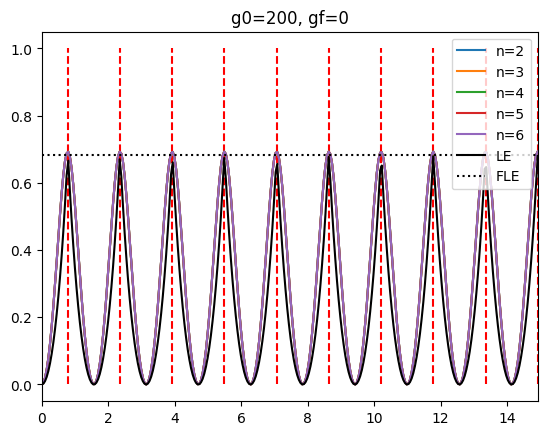

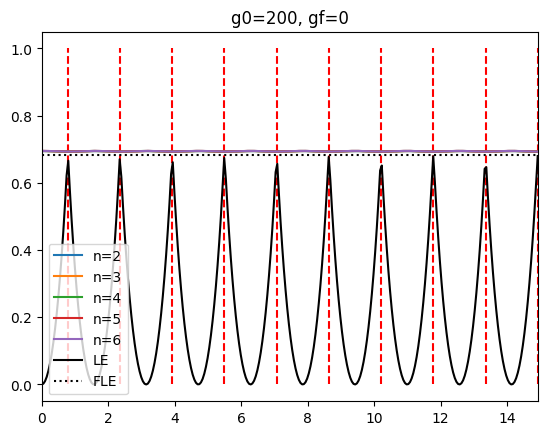

In [235]:
####
#Grab Final States
uf,vf,_=landau_states(L,gf,gf,array([0,.01]))[0][0]
d = GS_overlap(states,L,g0)
f = GS_overlap(states,L,gf)

#Calculate Projections
PZ=array( [
    [-log(zz.P_n(ni,s))/ni for ni in ns] for s in states
] )
PX = array([
    [-log(kz.P_n(ni,s))/ni for ni in ns] for s in states
])

###Plotting###

#### Z projectors ####
for tn in tns:
    plt.vlines(tn,0,1,colors="red",ls="--")
for p,n in zip(PZ.T,ns):
    plot(t_eval,p,label=f"n={n}")
plot(t_eval,-log(d)/L,color="black",label=r"LE")
plot(t_eval,-log(f)/L,color="black",ls=":",label=r"FLE")

title(f"g0={g0}, gf={gf}")
xlim(t_eval[0],t_eval[-1])
legend()

show()
#### X projectors ####
for tn in tns:
    plt.vlines(tn,0,1,colors="red",ls="--")
for p,n in zip(PX.T,ns):
    plot(t_eval,p,label=f"n={n}")
plot(t_eval,-log(d)/L,color="black",label=r"LE")
plot(t_eval,-log(f)/L,color="black",ls=":",label=r"FLE")
title(f"g0={g0}, gf={gf}")
xlim(t_eval[0],t_eval[-1])
legend()